<a href="https://colab.research.google.com/github/Ngwijabagabo/Groundwater_Storage_pred/blob/main/SDG_15_3_1_GEE_Gatsibo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 SDG 15.3.1 — Land Degradation Modelling
### LADM 0706515 · Google Earth Engine Practical Notebook
**University of Rwanda · College of Science and Technology**  
School of Architecture and Built Environment · Department of Spatial Planning · AY 2023

---

### Study Area: Gatsibo District, Eastern Province, Rwanda
- **GEE Asset:** `projects/ee-ngwijabagabohyacinthe/assets/Study_Gatsibo`
- **API Account:** `ee-ngwijabagabohyacinthe`

---

## 📋 Course Overview & Learning Outcomes

This practical guides you through computing **SDG Indicator 15.3.1** — the proportion of degraded land — for Gatsibo District using Google Earth Engine (GEE). You will implement the full **UNCCD Good Practice Guidance (GPG)** pipeline.

### The Three Sub-Indicators

| Sub-Indicator | Data Source | Description |
|---|---|---|
| **Land Productivity** | MODIS MOD13Q1 | NDVI trajectory, state, and performance |
| **Land Cover** | ESA CCI | Transitions reclassified to 7 UNCCD classes |
| **Soil Organic Carbon (SOC)** | SoilGrids + IPCC | Baseline + land-use change coefficients |

### Integration Rule — One-Out All-Out (1OAO)
If **any** sub-indicator shows degradation → pixel = **degraded**

$$\text{SDG 15.3.1} = \frac{\text{Degraded area}}{\text{Total land area}} \times 100\%$$

### Baseline & Reporting Periods
| Period | Years | Purpose |
|---|---|---|
| **Baseline** | 2001–2015 | Reference condition for all sub-indicators |
| **Reporting** | 2016–2023 | Assessment of change relative to baseline |

---

## 🗺️ Workflow
```
M1 Setup → M2 Land Productivity (NDVI/MODIS) → M3 Land Cover (ESA CCI) → M4 SOC → M5 SDG 15.3.1
```

---
# Module 1 · Setup & Study Area
**Objectives:** Authenticate with GEE, load the Gatsibo District boundary, and visualize the study area.

In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install earthengine-api geemap folium -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.7 MB/s eta 0:00:00


In [2]:
# ── M1.1 · Authenticate and Initialize GEE ───────────────────────────────────
import ee
import geemap
import folium
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Authenticate (opens browser window — follow the link and paste the token)
ee.Authenticate()

# Initialize with your GEE project
ee.Initialize(project='ee-ngwijabagabohyacinthe')
print('✅ GEE initialized successfully')

✅ GEE initialized successfully


In [3]:
# ── M1.2 · Load Study Area (Gatsibo District) ─────────────────────────────────
# Load the uploaded shapefile asset
aoi = ee.FeatureCollection('projects/ee-ngwijabagabohyacinthe/assets/Study_Gatsibo')

# Get geometry for spatial operations
aoi_geom = aoi.geometry()

# Print basic info
area_ha = aoi_geom.area().divide(1e4).getInfo()
print(f'📍 Study Area: Gatsibo District, Eastern Province, Rwanda')
print(f'📐 Total Area: {area_ha:,.0f} hectares ({area_ha/100:.0f} km²)')
print(f'✅ Asset loaded: {aoi.size().getInfo()} feature(s)')

📍 Study Area: Gatsibo District, Eastern Province, Rwanda
📐 Total Area: 192,922 hectares (1929 km²)
✅ Asset loaded: 1 feature(s)


In [4]:
# ── M1.3 · Visualize Study Area ───────────────────────────────────────────────
Map = geemap.Map()
Map.centerObject(aoi_geom, zoom=9)

# Add boundary
Map.addLayer(aoi, {'color': 'FF0000'}, 'Gatsibo District Boundary')

# Add Sentinel-2 True Colour for context (2022)
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi_geom)
        .filterDate('2022-01-01', '2022-12-31')
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .median()
        .clip(aoi_geom))

Map.addLayer(s2, {'bands': ['B4','B3','B2'], 'min': 0, 'max': 3000}, 'Sentinel-2 True Colour 2022')
Map.addLayerControl()
Map

Map(center=[-1.8451649741730027, 30.64096548586689], controls=(WidgetControl(options=['position', 'transparent…

---
# Module 2 · Land Productivity (NDVI / MODIS MOD13Q1)

**Data:** MODIS MOD13Q1 (16-day composite, 250 m)  
**Baseline:** 2001–2015 | **Reporting:** 2016–2023  

The **Land Productivity** sub-indicator is composed of three components:

| Component | Description |
|---|---|
| **Trajectory** | Long-term NDVI trend (Mann-Kendall or linear regression) |
| **Performance** | Current NDVI vs. potential (90th percentile of land-cover peers) |
| **State** | Current NDVI mean vs. baseline mean |

> **Degraded** if Trajectory < 0 **OR** Performance < 0.5 **OR** State < −10%

In [5]:
# ── M2.1 · Load MODIS MOD13Q1 NDVI ───────────────────────────────────────────
def load_ndvi(start_year, end_year):
    """Load annual mean NDVI from MODIS MOD13Q1."""
    collection = (ee.ImageCollection('MODIS/061/MOD13Q1')
                    .filterBounds(aoi_geom)
                    .filterDate(f'{start_year}-01-01', f'{end_year}-12-31')
                    .select('NDVI'))
    # Scale factor
    def scale_ndvi(img):
        return img.multiply(0.0001).copyProperties(img, ['system:time_start'])
    return collection.map(scale_ndvi)

# Baseline (2001-2015) and Reporting (2016-2023)
ndvi_baseline  = load_ndvi(2001, 2015)
ndvi_reporting = load_ndvi(2016, 2023)
ndvi_all       = load_ndvi(2001, 2023)

print(f'📦 Baseline  images : {ndvi_baseline.size().getInfo()}')
print(f'📦 Reporting images : {ndvi_reporting.size().getInfo()}')

📦 Baseline  images : 345
📦 Reporting images : 184


In [6]:
# ── M2.2 · Trajectory — Linear Trend (2001–2023) ─────────────────────────────
def add_time_band(image):
    """Add a time band (years since 2001) for trend fitting."""
    year = ee.Date(image.get('system:time_start')).get('year').subtract(2001)
    time_band = ee.Image.constant(year).float().rename('time')
    return image.addBands(time_band)

ndvi_with_time = ndvi_all.map(add_time_band)

# Fit linear regression: NDVI = a + b*time
trend = ndvi_with_time.select(['time', 'NDVI']).reduce(ee.Reducer.linearFit())

# Slope (b): positive = improving, negative = degrading
slope = trend.select('scale').clip(aoi_geom)

# Classify trajectory
# Degraded = slope < −0.001 per year (≈5% decline over 20 years)
trajectory_degraded = slope.lt(-0.001).rename('trajectory_degraded')

print('✅ NDVI trajectory computed')
print(f'   Threshold: slope < -0.001 per year → Degraded')

✅ NDVI trajectory computed
   Threshold: slope < -0.001 per year → Degraded


In [7]:
# ── M2.3 · State — Baseline vs. Reporting Mean NDVI ──────────────────────────
ndvi_baseline_mean  = ndvi_baseline.mean().clip(aoi_geom)
ndvi_reporting_mean = ndvi_reporting.mean().clip(aoi_geom)

# Percentage change: (reporting - baseline) / baseline * 100
ndvi_state_change = (ndvi_reporting_mean.subtract(ndvi_baseline_mean)
                                        .divide(ndvi_baseline_mean)
                                        .multiply(100)
                                        .rename('state_change_pct'))

# Degraded if NDVI declined by more than 10% relative to baseline
state_degraded = ndvi_state_change.lt(-10).rename('state_degraded')

print('✅ NDVI state computed')
print(f'   Threshold: change < -10% → Degraded')

✅ NDVI state computed
   Threshold: change < -10% → Degraded


In [8]:
# ── M2.4 · Performance — Current vs. Potential NDVI ──────────────────────────
# Potential = 90th percentile of NDVI across the entire study period
ndvi_potential = ndvi_all.reduce(ee.Reducer.percentile([90])).clip(aoi_geom)

# Performance ratio: current mean / potential
performance_ratio = (ndvi_reporting_mean
                       .divide(ndvi_potential)
                       .rename('performance_ratio'))

# Degraded if performance < 0.5 (below 50% of potential)
performance_degraded = performance_ratio.lt(0.5).rename('performance_degraded')

print('✅ NDVI performance computed')
print(f'   Threshold: ratio < 0.5 → Degraded')

✅ NDVI performance computed
   Threshold: ratio < 0.5 → Degraded


In [9]:
# ── M2.5 · Land Productivity Sub-Indicator (1OAO) ─────────────────────────────
# A pixel is productivity-degraded if ANY of the three components shows degradation
lp_degraded = (trajectory_degraded
               .Or(state_degraded)
               .Or(performance_degraded)
               .rename('land_productivity_degraded'))

# Visualize
Map2 = geemap.Map()
Map2.centerObject(aoi_geom, zoom=9)
Map2.addLayer(aoi, {'color': 'FF0000'}, 'Gatsibo District')

ndvi_vis  = {'min': 0.0, 'max': 0.8, 'palette': ['red','yellow','green']}
slope_vis = {'min': -0.005, 'max': 0.005, 'palette': ['d73027','fee08b','1a9850']}
deg_vis   = {'min': 0, 'max': 1, 'palette': ['white', 'darkred']}

Map2.addLayer(ndvi_baseline_mean,  ndvi_vis,  'NDVI Baseline Mean (2001-2015)')
Map2.addLayer(ndvi_reporting_mean, ndvi_vis,  'NDVI Reporting Mean (2016-2023)')
Map2.addLayer(slope,               slope_vis, 'NDVI Trend Slope')
Map2.addLayer(lp_degraded,         deg_vis,   'Land Productivity Degraded')
Map2.addLayerControl()

# Statistics
lp_area = (lp_degraded.multiply(ee.Image.pixelArea())
                       .reduceRegion(reducer=ee.Reducer.sum(),
                                     geometry=aoi_geom, scale=250,
                                     maxPixels=1e10)
                       .get('land_productivity_degraded').getInfo())
print(f'\n📊 Land Productivity — Degraded Area: {lp_area/1e4:,.0f} ha')
print(f'   ({lp_area/area_ha/1e4*100:.1f}% of Gatsibo District)')
Map2


📊 Land Productivity — Degraded Area: 79,667 ha
   (41.3% of Gatsibo District)


Map(center=[-1.8451649741729912, 30.640965485866897], controls=(WidgetControl(options=['position', 'transparen…

---
# Module 3 · Land Cover Change (ESA CCI)

**Data:** ESA Climate Change Initiative (CCI) Land Cover v2.1.1 (300 m, annual)  

The **Land Cover** sub-indicator identifies pixels that transitioned from a **higher-value** to a **lower-value** UNCCD land cover class between the baseline and reporting periods.

### UNCCD 7-Class Reclassification

| UNCCD Class | Value | ESA CCI Codes |
|---|---|---|
| Tree-covered areas | 1 | 50, 60, 61, 62, 70, 71, 72, 80, 81, 82, 90, 100, 160, 170 |
| Grassland | 2 | 110, 130 |
| Cropland | 3 | 10, 11, 12, 20, 30, 40 |
| Wetland | 4 | 160, 180 |
| Artificial surfaces | 5 | 190 |
| Other land | 6 | 120, 121, 122, 140, 150, 151, 152, 153, 200, 201, 202, 220 |
| Water bodies | 7 | 210 |

> **Degradation transition matrix**: Conversion FROM class 1 (trees) or 2 (grassland) TO class 5 (artificial), 6 (other) = degraded

In [12]:
# ── M3.1 · Load MODIS MCD12Q1 Land Cover ─────────────────────────────────────
def get_modis_lc(year):
    """Load annual MODIS MCD12Q1 Land Cover (IGBP type 1)."""
    # Filter for the specific year and select the IGBP classification band.
    # MCD12Q1 provides annual land cover maps.
    collection = (ee.ImageCollection('MODIS/061/MCD12Q1')
                    .filterBounds(aoi_geom)
                    .filterDate(f'{year}-01-01', f'{year}-12-31')
                    .select('LC_Type1')) # IGBP classification

    # Get the first image for the year. MCD12Q1 images represent the entire year.
    return collection.first().clip(aoi_geom).rename('lc')

# Baseline (2001) and Reporting (2022)
lc_base   = get_modis_lc(2001)
lc_report = get_modis_lc(2022)

print('✅ MODIS MCD12Q1 Land Cover loaded for baseline (2001) and reporting (2022)')


✅ MODIS MCD12Q1 Land Cover loaded for baseline (2001) and reporting (2022)


In [16]:
# ── M3.2 · Reclassify MODIS IGBP → 7 UNCCD Classes ───────────────────────────
# Map MODIS IGBP Land Cover Type 1 (LC_Type1) to 7 UNCCD classes.
# See MODIS User Guide for LC_Type1 definitions.

# From values (MODIS IGBP codes) → to values (UNCCD class)
# Tree-covered = 1, Grassland = 2, Cropland = 3, Wetland = 4,
# Artificial = 5, Other = 6, Water = 7

from_vals = [
    # Tree-covered areas (1): IGBP 1-5 (Forests)
    1, 2, 3, 4, 5,
    # Grassland (2): IGBP 10 (Grasslands)
    10,
    # Cropland (3): IGBP 12 (Croplands), 14 (Cropland/Natural Vegetation Mosaics)
    12, 14,
    # Wetland (4): IGBP 11 (Permanent Wetlands)
    11,
    # Artificial surfaces (5): IGBP 13 (Urban and Built-up)
    13,
    # Other land (6): IGBP 6-9 (Shrublands, Savannas), 15 (Snow and Ice), 16 (Barren)
    6, 7, 8, 9, 15, 16,
    # Water bodies (7): IGBP 17 (Water Bodies)
    17
]
to_vals = (
    [1]*5 +  # Tree-covered
    [2]*1  +  # Grassland
    [3]*2  +  # Cropland
    [4]*1  +  # Wetland
    [5]*1  +  # Artificial
    [6]*6  +  # Other land
    [7]*1     # Water
)

def reclassify(img):
    # Any unmapped MODIS classes will default to 'Other land' (6)
    return img.remap(from_vals, to_vals, defaultValue=6).rename('unccd_class')

lc_base_7   = reclassify(lc_base)
lc_report_7 = reclassify(lc_report)

print('✅ Reclassification complete → 7 UNCCD classes (from MODIS IGBP)')

# Visualize
pal = ['006400','a4d65e','f5e642','00bfff','c0c0c0','d2b48c','0000ff'] # Keep original palette for UNCCD classes
Map3 = geemap.Map()
Map3.centerObject(aoi_geom, zoom=9)
Map3.addLayer(lc_base_7,   {'min':1,'max':7,'palette':pal}, 'Land Cover Baseline (2001)')
Map3.addLayer(lc_report_7, {'min':1,'max':7,'palette':pal}, 'Land Cover Reporting (2022)')
Map3.addLayer(aoi, {'color':'FF0000'}, 'Gatsibo Boundary')
Map3.addLayerControl()
Map3


✅ Reclassification complete → 7 UNCCD classes (from MODIS IGBP)


Map(center=[-1.8451649741730027, 30.64096548586689], controls=(WidgetControl(options=['position', 'transparent…

In [14]:
# ── M3.3 · Land Cover Change — Degradation Detection ─────────────────────────
# UNCCD degradation logic:
#   Trees (1) → Any lower class = degraded
#   Grassland (2) → Artificial (5) or Other (6) = degraded
#   Cropland (3) → Artificial (5) or Other (6) = degraded
#   Wetland (4) → Any lower class = degraded

# Encode as combined change image: baseline*10 + reporting
# E.g., transition 1→5 = 15, transition 2→6 = 26
change_code = lc_base_7.multiply(10).add(lc_report_7).rename('change_code')

# Define degraded transitions
degraded_codes = [
    15, 16,  # trees → artificial, other
    25, 26,  # grassland → artificial, other
    35, 36,  # cropland → artificial, other
    41, 42, 43, 45, 46,  # wetland → trees, grass, crop, artificial, other
    13, 14, 15, 16, 17,  # trees → cropland, wetland, artificial, other, water
]

# Mark as degraded (1) if code is in degraded_codes list
lc_degraded = change_code.remap(degraded_codes, [1]*len(degraded_codes), defaultValue=0)
lc_degraded = lc_degraded.rename('lc_degraded').clip(aoi_geom)

# Compute area
lc_area = (lc_degraded.multiply(ee.Image.pixelArea())
                       .reduceRegion(reducer=ee.Reducer.sum(),
                                     geometry=aoi_geom, scale=300,
                                     maxPixels=1e10)
                       .get('lc_degraded').getInfo())

print(f'📊 Land Cover — Degraded Area: {lc_area/1e4:,.0f} ha')
Map3.addLayer(lc_degraded, {'min':0,'max':1,'palette':['white','darkred']}, 'LC Degraded Transitions')
Map3


📊 Land Cover — Degraded Area: 3,817 ha


Map(bottom=66585.0, center=[-2.05674807933553, 30.643634870597445], controls=(WidgetControl(options=['position…

---
# Module 4 · Soil Organic Carbon (SOC)

**Data:** SoilGrids v2.0 (250 m) + IPCC land-use change coefficients  

### Method
1. Load SoilGrids SOC stock at 0–30 cm depth (baseline)
2. Apply IPCC Tier 1 coefficients based on land-cover transitions
3. Estimate SOC stock change between baseline and reporting period
4. Flag pixels with SOC **decline > 10%** as degraded

### IPCC Relative Stock Change Factors (F_LU) for Sub-Humid Tropics

| Transition | F_LU |
|---|---|
| Forest → Cropland | 0.48 |
| Forest → Grassland | 0.69 |
| Grassland → Cropland | 0.59 |
| Cropland → Grassland | 1.17 |
| Any → Forest | 1.00 |

In [15]:
# ── M4.1 · Load SoilGrids SOC Stock ──────────────────────────────────────────
# SOC stock in kg C/m² at 0-30 cm
# SoilGrids: OpenLandMap or direct GEE asset
soc_baseline = (ee.Image('OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02')
                  .select('b0')  # 0-5 cm; combine depths for 0-30
                  .clip(aoi_geom))

# Scale: value * 5 = g C/kg soil → convert to tC/ha
# Full 0-30cm estimate using weighted depths
def load_soc_depth(band, depth_cm):
    img = (ee.Image('OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02')
             .select(band)
             .multiply(5)  # g/kg
             .clip(aoi_geom))
    # Convert g/kg to tC/ha assuming bulk density 1.3 g/cm³
    # tC/ha = g/kg * bulk_density(g/cm³) * depth(m) * 10000(m²/ha) / 1e6
    return img.multiply(1.3 * (depth_cm/100) * 10000 / 1e6)

soc_0_5   = load_soc_depth('b0', 5)
soc_5_15  = load_soc_depth('b10', 10)
soc_15_30 = load_soc_depth('b30', 15)

# Total 0-30 cm SOC stock (tC/ha)
soc_stock = soc_0_5.add(soc_5_15).add(soc_15_30).rename('soc_tC_ha')

print('✅ SoilGrids SOC loaded (0-30 cm)')
soc_stats = soc_stock.reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.minMax(), sharedInputs=True),
    geometry=aoi_geom, scale=250, maxPixels=1e10).getInfo()
print(f'   Mean SOC: {soc_stats.get("soc_tC_ha_mean", "N/A"):.1f} tC/ha')


✅ SoilGrids SOC loaded (0-30 cm)
   Mean SOC: 0.1 tC/ha


In [17]:
# ── M4.2 · Apply IPCC Tier 1 Coefficients to Estimate SOC Change ─────────────
# Use the land-cover change codes computed in Module 3
# F_LU values for Sub-Humid Tropics (IPCC 2006 Table 5.5)

# Map each transition code to its F_LU factor
# change_code = base_class*10 + report_class
flu_from = [11, 12, 13, 21, 22, 23, 31, 32, 33]  # stable + transitions
flu_vals  = [1.00, 1.00, 0.48,   # forest→forest, forest→grass, forest→crop
             0.69, 1.00, 0.59,   # grass→forest, grass→grass, grass→crop
             1.00, 1.17, 1.00]   # crop→forest, crop→grass, crop→crop

# Build F_LU image from transition map
flu_image = change_code.remap(flu_from, flu_vals, defaultValue=1.0).rename('F_LU')

# Reporting SOC = Baseline SOC × F_LU
# (simplified; assumes 20-year equilibration period)
soc_reporting = soc_stock.multiply(flu_image).rename('soc_reporting')

# SOC change (%)
soc_change_pct = (soc_reporting.subtract(soc_stock)
                               .divide(soc_stock)
                               .multiply(100)
                               .rename('soc_change_pct'))

# Degraded if SOC declined >10%
soc_degraded = soc_change_pct.lt(-10).rename('soc_degraded')

print('✅ SOC change estimated via IPCC Tier 1 coefficients')

Map4 = geemap.Map()
Map4.centerObject(aoi_geom, zoom=9)
Map4.addLayer(soc_stock,   {'min':10,'max':80,'palette':['f5f5f5','d6b17a','8b4513']}, 'SOC Baseline (tC/ha)')
Map4.addLayer(soc_change_pct, {'min':-40,'max':40,'palette':['d73027','fee08b','1a9850']}, 'SOC % Change')
Map4.addLayer(soc_degraded, {'min':0,'max':1,'palette':['white','darkred']}, 'SOC Degraded')
Map4.addLayer(aoi, {'color':'FF0000'}, 'Gatsibo Boundary')
Map4.addLayerControl()
Map4

✅ SOC change estimated via IPCC Tier 1 coefficients


Map(center=[-1.8451649741730027, 30.64096548586689], controls=(WidgetControl(options=['position', 'transparent…

---
# Module 5 · SDG 15.3.1 — Integration (1OAO Rule)

**One-Out All-Out (1OAO):** A pixel is classified as **degraded** in the final SDG map if **at least one** sub-indicator shows degradation.

$$\text{Final Degradation} = LP_{deg} \cup LC_{deg} \cup SOC_{deg}$$

$$\boxed{\text{SDG 15.3.1} = \frac{\sum(\text{Degraded pixels} \times \text{pixel area})}{\text{Total land area}} \times 100\%}$$

In [18]:
# ── M5.1 · Combine Sub-Indicators (1OAO Rule) ─────────────────────────────────
# Resample all to common 300m resolution (coarsest: ESA CCI)
lp_300  = lp_degraded.reproject(crs='EPSG:4326', scale=300)
soc_300 = soc_degraded.reproject(crs='EPSG:4326', scale=300)
lc_300  = lc_degraded.reproject(crs='EPSG:4326', scale=300)

# 1OAO integration
sdg_degraded = lp_300.Or(lc_300).Or(soc_300).rename('sdg_degraded').clip(aoi_geom)

# Multi-layer view: which sub-indicators contribute
sdg_components = (ee.Image.cat([
    lp_300.rename('LP'),
    lc_300.rename('LC'),
    soc_300.rename('SOC'),
    sdg_degraded.rename('SDG')
]))

print('✅ 1OAO integration complete')

✅ 1OAO integration complete


In [19]:
# ── M5.2 · Compute SDG 15.3.1 Statistics ─────────────────────────────────────
pixel_area = ee.Image.pixelArea()

def get_degraded_area(img, band, scale=300):
    return (img.select(band).multiply(pixel_area)
               .reduceRegion(reducer=ee.Reducer.sum(),
                             geometry=aoi_geom,
                             scale=scale, maxPixels=1e10)
               .get(band).getInfo())

total_area  = aoi_geom.area().getInfo()   # m²
lp_area_m2  = get_degraded_area(sdg_components, 'LP')
lc_area_m2  = get_degraded_area(sdg_components, 'LC')
soc_area_m2 = get_degraded_area(sdg_components, 'SOC')
sdg_area_m2 = get_degraded_area(sdg_components, 'SDG')

def ha(m2): return m2 / 1e4
def pct(m2): return m2 / total_area * 100

print('=' * 55)
print('     SDG 15.3.1 Results — Gatsibo District, Rwanda')
print('=' * 55)
print(f'  Total Land Area    : {ha(total_area):>10,.0f} ha')
print('-' * 55)
print(f'  Land Productivity  : {ha(lp_area_m2):>10,.0f} ha  ({pct(lp_area_m2):.1f}%)')
print(f'  Land Cover Change  : {ha(lc_area_m2):>10,.0f} ha  ({pct(lc_area_m2):.1f}%)')
print(f'  SOC Change         : {ha(soc_area_m2):>10,.0f} ha  ({pct(soc_area_m2):.1f}%)')
print('-' * 55)
print(f'  ★ SDG 15.3.1 (1OAO): {ha(sdg_area_m2):>9,.0f} ha  ({pct(sdg_area_m2):.1f}%)')
print('=' * 55)

     SDG 15.3.1 Results — Gatsibo District, Rwanda
  Total Land Area    :    192,922 ha
-------------------------------------------------------
  Land Productivity  :     78,996 ha  (40.9%)
  Land Cover Change  :      3,918 ha  (2.0%)
  SOC Change         :      2,886 ha  (1.5%)
-------------------------------------------------------
  ★ SDG 15.3.1 (1OAO):    68,924 ha  (35.7%)


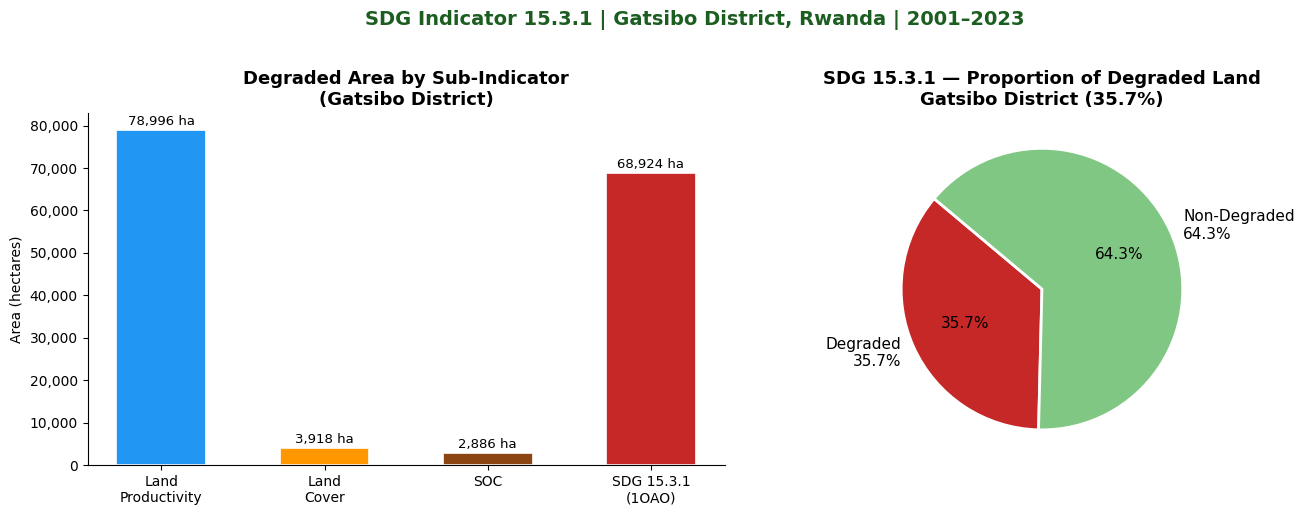

📊 Chart saved: SDG_15_3_1_Gatsibo_results.png


In [20]:
# ── M5.3 · Summary Chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart of degraded areas
labels = ['Land\nProductivity', 'Land\nCover', 'SOC', 'SDG 15.3.1\n(1OAO)']
areas  = [ha(lp_area_m2), ha(lc_area_m2), ha(soc_area_m2), ha(sdg_area_m2)]
colors = ['#2196F3','#FF9800','#8B4513','#C62828']

bars = axes[0].bar(labels, areas, color=colors, width=0.55, edgecolor='white', linewidth=1.2)
axes[0].set_title('Degraded Area by Sub-Indicator\n(Gatsibo District)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Area (hectares)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for bar, area in zip(bars, areas):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f'{area:,.0f} ha', ha='center', va='bottom', fontsize=9.5)
axes[0].spines[['top','right']].set_visible(False)

# Right: Pie chart of SDG 15.3.1
not_deg = ha(total_area) - ha(sdg_area_m2)
wedge_sizes = [ha(sdg_area_m2), not_deg]
wedge_colors = ['#C62828','#81C784']
wedge_labels = [f'Degraded\n{pct(sdg_area_m2):.1f}%', f'Non-Degraded\n{100-pct(sdg_area_m2):.1f}%']

axes[1].pie(wedge_sizes, labels=wedge_labels, colors=wedge_colors,
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 11},
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title(f'SDG 15.3.1 — Proportion of Degraded Land\nGatsibo District ({pct(sdg_area_m2):.1f}%)',
                  fontsize=13, fontweight='bold')

plt.suptitle('SDG Indicator 15.3.1 | Gatsibo District, Rwanda | 2001–2023',
             fontsize=14, fontweight='bold', y=1.02, color='#1B5E20')
plt.tight_layout()
plt.savefig('SDG_15_3_1_Gatsibo_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved: SDG_15_3_1_Gatsibo_results.png')

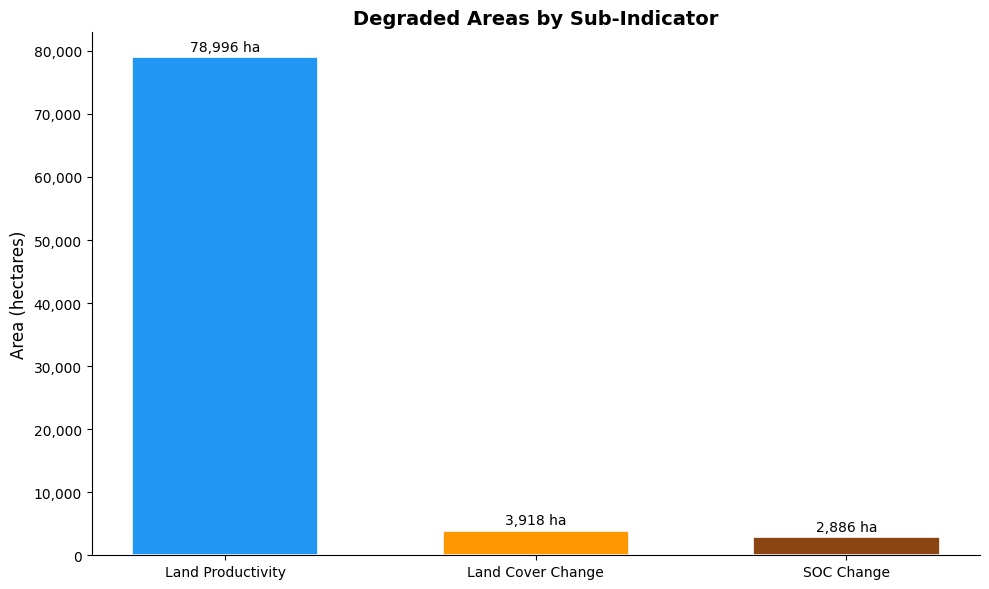

In [27]:
import matplotlib.pyplot as plt

# Data from previous calculations
sub_indicator_labels = ['Land Productivity', 'Land Cover Change', 'SOC Change']
sub_indicator_areas = [ha(lp_area_m2), ha(lc_area_m2), ha(soc_area_m2)]
sub_indicator_colors = ['#2196F3', '#FF9800', '#8B4513']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(sub_indicator_labels, sub_indicator_areas, color=sub_indicator_colors, width=0.6, edgecolor='white', linewidth=1.2)
ax.set_title('Degraded Areas by Sub-Indicator', fontsize=14, fontweight='bold')
ax.set_ylabel('Area (hectares)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.tick_params(axis='x', labelsize=10)

# Add labels on top of the bars
for bar, area in zip(bars, sub_indicator_areas):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500, # Adjust vertical position
            f'{area:,.0f} ha', ha='center', va='bottom', fontsize=10)

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [26]:
# ── M5.4 · Final SDG 15.3.1 Map ───────────────────────────────────────────────
Map5 = geemap.Map()
Map5.centerObject(aoi_geom, zoom=9);

# Classified degradation map
Map5.addLayer(sdg_degraded,
              {'min':0,'max':1,'palette':['#B2DFDB','#C62828']},
              'SDG 15.3.1 — Degradation (1OAO)');

# Individual sub-indicators for comparison
Map5.addLayer(lp_300, {'min':0,'max':1,'palette':['white','#1565C0']}, 'Land Productivity Degraded', False);
Map5.addLayer(lc_300, {'min':0,'max':1,'palette':['white','#E65100']}, 'Land Cover Degraded', False);
Map5.addLayer(soc_300,{'min':0,'max':1,'palette':['white','#4E342E']}, 'SOC Degraded', False);
Map5.addLayer(aoi, {'color':'000000'}, 'Gatsibo Boundary');

# Add the LP & SOC Overlap layer
Map5.addLayer(lp_soc_overlap, {'min':0,'max':1,'palette':['white','#4CAF50']}, 'LP & SOC Overlap', False);

# Add a legend for the SDG 15.3.1 degradation layer
legend_keys = ['Non-Degraded', 'Degraded (1OAO)'];
legend_colors = ['#B2DFDB','#C62828'];
Map5.add_legend(keys=legend_keys, colors=legend_colors, title='SDG 15.3.1 Status');

Map5.addLayerControl()
Map5

Map(center=[-1.8451649741730027, 30.64096548586689], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
# ── M5.5 · Export Final Map to Google Drive ───────────────────────────────────
export_task = ee.batch.Export.image.toDrive(
    image=sdg_degraded.unmask(0).byte(),
    description='SDG_15_3_1_Gatsibo_2001_2023',
    folder='GEE_LADM0706515',
    fileNamePrefix='SDG_15_3_1_Gatsibo',
    region=aoi_geom,
    scale=300,
    crs='EPSG:32736',  # UTM Zone 36S (Rwanda)
    maxPixels=1e13
)
export_task.start()
print('🚀 Export task started!')
print(f'   Status: {export_task.status()["state"]}')
print('   Monitor at: https://code.earthengine.google.com/tasks')

## 📊 Overlap Analysis

In [25]:
# ── M5.6 · Overlap between LP and SOC Degradation ───────────────────────────

# Compute the intersection: where both LP and SOC are degraded
lp_soc_overlap = lp_300.And(soc_300).rename('lp_soc_overlap')

# Calculate the area of this overlap
lpsoc_overlap_area_m2 = get_degraded_area(lp_soc_overlap, 'lp_soc_overlap', scale=300)

print(f'📊 Overlap Area (LP and SOC degraded): {ha(lpsoc_overlap_area_m2):,.0f} ha')
print(f'   ({pct(lpsoc_overlap_area_m2):.1f}% of Gatsibo District)')

# Visualize the overlap
Map_overlap = geemap.Map()
Map_overlap.centerObject(aoi_geom, zoom=9)
Map_overlap.addLayer(lp_soc_overlap, {'min':0,'max':1,'palette':['white','#4CAF50']}, 'LP & SOC Overlap')
Map_overlap.addLayer(aoi, {'color':'000000'}, 'Gatsibo Boundary')

# Add a legend for the overlap layer
legend_keys_overlap = ['Non-Overlap', 'LP & SOC Degraded']
legend_colors_overlap = ['white','#4CAF50']
Map_overlap.add_legend(keys=legend_keys_overlap, colors=legend_colors_overlap, title='LP & SOC Degradation Overlap')
Map_overlap.addLayerControl()
Map_overlap

📊 Overlap Area (LP and SOC degraded): 1,504 ha
   (0.8% of Gatsibo District)


Map(center=[-1.8451649741730027, 30.64096548586689], controls=(WidgetControl(options=['position', 'transparent…

---
## 📝 Summary & Interpretation

### Results Table

| Sub-Indicator | Method | Threshold | Degraded Area |
|---|---|---|---|
| Land Productivity | Linear NDVI trend + State + Performance | Slope < −0.001/yr; State < −10%; Perf. < 0.5 | See output above |
| Land Cover | ESA CCI transition matrix (7 UNCCD classes) | Degrading transition | See output above |
| SOC | SoilGrids + IPCC Tier 1 F_LU factors | SOC decline > 10% | See output above |
| **SDG 15.3.1 (1OAO)** | **Any sub-indicator degraded** | — | **See output above** |

### Key Takeaways
- The **1OAO rule** tends to give a **conservative (higher) estimate** of degraded area
- SDG 15.3.1 should be reported alongside disaggregated sub-indicator maps
- Uncertainty arises from data resolution (MODIS 250m, ESA 300m, SoilGrids 250m)
- Ground-truthing is recommended before reporting to national authorities

### References
- UNCCD (2021). *Good Practice Guidance for SDG Indicator 15.3.1*. Version 2.0
- Trends.Earth platform (Conservation International, 2022)
- ESA CCI Land Cover v2.1.1 — https://www.esa-landcover-cci.org
- SoilGrids v2.0 — https://soilgrids.org
- MODIS MOD13Q1 — NASA LP DAAC